<h1><center>Laboratorio 8: Predicciones y Recomendaciones 🔮🪄 </center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2024</strong></center>

### **Cuerpo Docente:**

- Profesores: Ignacio Meza, Sebastián Tinoco
- Auxiliar: Eduardo Moya
- Ayudantes: Nicolás Ojeda, Melanie Peña, Valentina Rojas

### **Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados**

- Nombre de alumno 1: María Jesus Espinoza
- Nombre de alumno 2: Sofía Lazcano 

### **Link de repositorio de GitHub:** https://github.com/jesuow/LabPro

## Temas a tratar
- Series de Tiempo.
- Predicciones vía `Prophet`.
- Implementar un sistema de recomendación utilizando `surprise`.

## Reglas:

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibidas las copias.
- Pueden usar cualquer matrial del curso que estimen conveniente.
- Código que no se pueda ejecutar, no será revisado.

### Objetivos principales del laboratorio
- Comprender qué es una serie de tiempo y su estructura.
- Identificar tendencias, estacionalidades e irregularidades.
- Armar un modelo predictivo para la serie.
- Conocer y aplicar sistemas de recomendación.
- Entender estructura y conocer casos de estudio.


In [103]:
# Si usted está utilizando Colabolatory le puede ser útil este código para cargar los archivos.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    path = 'Dirección donde tiene los archivos en el Drive'
except:
    print('Ignorando conexión drive-colab')

Ignorando conexión drive-colab


In [104]:
# Librerias globales

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import plotly.express as px

# **1. Forecasting (30 puntos)**


## **Prophet**

Prophet es una herramienta open-source de Facebook utilizada para realizar predicciones en series de tiempo. Esta se basa en la descomposición aditiva, donde tendencias no lineales se ajustan junto a la estacionalidad.

En la ecuación de a continuación se puede ver una idea general de los elementos que construyen a un modelo aditivo como lo es Prophet.

\begin{equation}
y(t) = g(t) + s(t) + h(t) + e(t)
\end{equation}

Donde, $g(t)$ hace referencia a las tendencias, que corresponden a cambios graduales en largos periodos de tiempo. $s(t)$ corresponde a la estacionalidad, son cambios periodicos o cortos en el tiempo. $h(t)$ es el efecto que tienen las festividades sobre las predicciones, mientras que e(t) corresponde al error o ruido. Finalmente $y(t)$, es la predicción hecha por el modelo.

Prophet trabaja por defecto con Piece-Wise Lineal Model, este es un modelo de regresión lineal, en el cual se buscan distintas zonas en que la data presente patrones o tendencias lineales, de estas zonas obtiene su regresión y luego las "une" de manera de representar toda la región, como se puede ver en la ecuación siguiente.

\begin{equation}
y(x)=
    \begin{cases}
        η_1 + \beta_1(x-b_1), & b_1 < x  \leqslant b_2 \\
        η_2 + \beta_2(x-b_2), & b_2 < x  \leqslant b_3 \\
        η_3 + \beta_3(x-b_3), & b_3 < x  \leqslant b_3 \\
        ... \\
        η_k + \beta_{nb}(x-b_{nb-1}), & b_{n-1} < x  \leqslant b_{nb} \\
    \end{cases}
\end{equation}

Siendo $b_1$ el primer punto de quiebre en la serie y así hasta el punto $b_{nb}$ correspondiente al último punto de quiebre de la serie con una cantidad $nb$ de puntos.

Para mayor información de Prophet y como utilizarla, pueden ver su [documentación](https://facebook.github.io/prophet/docs/quick_start.html#python-api), donde hay pueden encontrar un pequeño tutorial de la librería.

## **La Factura de Homero**

<center>
<img src ="https://i.makeagif.com/media/7-30-2018/H_ZAY1.gif" width = 500 />

Homero Simpson ha trabajado en la Planta Nuclear de Springfield por más de 20 años como Inspector de Seguridad, pero recientemente el Sr. Burns le ha permitido trabajar desde casa. Aunque le encanta la flexibilidad que esto le otorga, también ha notado un aumento considerable en su consumo energético en el hogar. Con el uso constante de calefacción en invierno y aire acondicionado en verano, Homero está preocupado por cómo afectará esto a su presupuesto en los próximos meses, ya que planea pasar aún más tiempo en casa.

Afortunadamente, gracias a su puesto en la Planta de Energía Nuclear, Homero tiene acceso a los datos de consumo de energía de cada ciudadano en Springfield, por lo que accede a esta información y almacena el consumo de su hogar en un archivo llamado `energia_homero.csv`. Este archivo posee el consumo diario en el hogar de Homero Simpson desde el Junio del 2016 hasta Julio del 2020.

Con esta valiosa información, Homero espera poder predecir su consumo energético y tomar decisiones informadas para ajustar su presupuesto mensual.

Los datos son los siguientes:

* **date**: Fecha de medición.
* **Energy_kWh**: Consumo diario de energía eléctrica en el hogar de Homero (en kWh).

## 1.1 Series de Tiempo [0 puntos]

### Carga de los datos

En primer lugar, cargue los datos históricos del archivo `energia_homero.csv` al entorno de trabajo. Una vez cargados, asegúrense de transformar la columna `date` a formato `datetime`. Además, visualice el consumo de energía en la casa de Homero mediante la librería `plotly`.


**Respuesta**:

In [105]:
df = pd.read_csv("energia_homero.csv") # leer datos
df['date'] = pd.to_datetime(df['date']) # formatear date como datetime

df.head()

,date,Energy_kWh
0,2016-06-01,29.691
1,2016-06-02,28.789
2,2016-06-03,19.247
3,2016-06-04,22.883
4,2016-06-05,25.195


In [107]:
fig = px.histogram(df, x='Energy_kWh', title='Distribución de consumo de energía')
fig.show()

In [106]:
fig = px.line(df, x='date', y='Energy_kWh', title='Consumo Energético a lo Largo del Tiempo')

fig.show()

## 1.2 Controlando la Serie de Tiempo [6 puntos]

<center>
<img src ="https://i.pinimg.com/originals/66/77/88/667788e0b1f08ff1e1cfce11d303b203.gif" width = 500 />

Luego de leer mucho, Homero cree que necesita descomponer la serie de tiempo para poder controlar estos componentes de forma efectiva y lograr que la serie tenga propiedades de una serie estacionaria.

Usted, como buen ciudadano de Springfield, decide ayudar a Homero, el cual le pide que realice lo siguientes pasos:

0. Cree un conjunto de entrenamiento y uno de prueba (a proyectar). Para ello, considere como entrenamiento la información **hasta** el `2020-02-29` y como conjunto de prueba **desde** el `2020-03-01`. [0 puntos]
1. Cree un `Pipeline` que permita obtener una representación de la tendencia de la serie de tiempo, mediante un modelo Lineal. Nombre al pipeline `Pipeline_trend`. [1 punto]
2. Entrene el modelo lineal y luego obtenga predicciones tanto para el conjunto de entrenamiento como para el de prueba (intervalo completo de tiempo). Luego grafique las predicciones y calcule el `Mean Absolute Error` (MAE), tanto para el conjunto de prueba como para el de entrenamiento. [1 punto]
3. Grafique el error (Valor real - Valor predicho) para todo el intervalo de tiempo y responda ¿Hay un comportamiento estacional en la serie? [1 punto]
4.  Cree un `Pipeline` que permita modelar la estacionalidad de la serie temporal mediante términos de Fourier y la represente a través de una Regresión Lineal de la variable objetivo. Nombre a este pipeline `Pipeline_seasonal`. Determine el valor de Periodos `P` y el número de terminos de Fourier `n`. [1 punto]
5. Entrene el nuevo modelo y obtenga predicciones en el intervalo completo de tiempo. Luego grafique y calcule el `MAE` en el conjunto de prueba y en el de entrenamiento. [1 punto]
6. Vuelva a graficar el error y comente los resultados. [1 punto]

**Respuesta**

In [108]:
#CODIGO AQUI

#----------- conjunto de entrenamiento y prueba
train_df = df[df['date'] <= '2020-02-29']
test_df = df[df['date'] >= '2020-03-01']

# Extraer variables de entrenamiento y prueba
X_train = train_df[['date']]
y_train = train_df['Energy_kWh']

X_test = test_df[['date']]
y_test = test_df['Energy_kWh']

In [109]:
#-----------1------------- pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

class TimeTransformer(TransformerMixin, BaseEstimator):
    def __init__(self):
        self.init_date = None

    def fit(self, X, y=None):
        assert isinstance(X, pd.DataFrame), 'X debe ser un DataFrame de pandas'
        assert 'date' in X.columns, 'La columna "date" debe estar presente'
        self.init_date = X.date.iloc[0]  # Guardar la fecha inicial
        return self

    def transform(self, X):
        X = X.copy()
        assert self.init_date is not None, 'El transformador debe estar ajustado primero (fit)'
        assert isinstance(X, pd.DataFrame), 'X debe ser un DataFrame de pandas'
        assert 'date' in X.columns, 'La columna "date" debe estar presente'

        final_date = X.date.iloc[-1]  # Última fecha del conjunto
        count = (final_date - self.init_date).days + 1
        X['trend'] = [i for i in range(count)][-len(X):]  # Generar la serie de tendencia
        return X[['trend']]

# Crear el Pipeline_trend
Pipeline_trend = Pipeline([
    ('time_features', TimeTransformer()),  # Aplica la tendencia
    ('linear_model', LinearRegression())   # Ajusta el modelo lineal
])

In [110]:
Pipeline_trend = Pipeline([
    ('time_features', TimeTransformer()),  # Aplica la tendencia
    ('linear_model', LinearRegression())   # Ajusta el modelo lineal
])

In [111]:
#----------------2----------- entrenamiento
Pipeline_trend.fit(train_df[['date']], train_df['Energy_kWh'])

Pipeline(steps=[('time_features', TimeTransformer()),
                ('linear_model', LinearRegression())])

In [112]:
from sklearn.metrics import mean_absolute_error

import plotly.graph_objects as go
#------------------------2----------------
# Get predictions for training and testing datasets
train_pred = Pipeline_trend.predict(train_df[['date']])  # Predictions for training set
test_pred = Pipeline_trend.predict(test_df[['date']])  # Predictions for testing set

# MAE for training dataset
mae_train = mean_absolute_error(train_df['Energy_kWh'], train_pred)

# MAE for testing dataset
mae_test = mean_absolute_error(test_df['Energy_kWh'], test_pred)

print(f"MAE - Training: {mae_train}")
print(f"MAE - Testing: {mae_test}")

# Gráfico del conjunto de entrenamiento y prueba
fig = go.Figure()
fig.add_trace(go.Scatter(x=train_df['date'], y=train_df['Energy_kWh'], mode='lines', name='Real Entrenamiento'))
fig.add_trace(go.Scatter(x=train_df['date'], y=train_pred, mode='lines', name='Predicción Entrenamiento'))
fig.add_trace(go.Scatter(x=test_df['date'], y=test_df['Energy_kWh'], mode='lines', name='Real Prueba'))
fig.add_trace(go.Scatter(x=test_df['date'], y=test_pred, mode='lines', name='Predicción Prueba'))
fig.update_layout(title='Predicciones del Modelo Lineal', xaxis_title='Fecha', yaxis_title='Consumo Energético (kWh)')
fig.show()

MAE - Training: 10.568154088025606
MAE - Testing: 8.655813997873523


In [113]:
#---------------------3------ Graficar el error
train_error = train_df['Energy_kWh'] - train_pred
test_error = test_df['Energy_kWh'] - test_pred

fig = go.Figure()
fig.add_trace(go.Scatter(x=train_df['date'], y=train_error, mode='lines', name='Error Entrenamiento'))
fig.add_trace(go.Scatter(x=test_df['date'], y=test_error, mode='lines', name='Error Prueba'))
fig.update_layout(title='Error del Modelo Lineal (Valor Real - Valor Predicho)', xaxis_title='Fecha', yaxis_title='Error')
fig.show()

#Pipeline Estacionalidad

In [114]:
from sklearn.base import BaseEstimator, TransformerMixin

class TimeTransformer(TransformerMixin, BaseEstimator):
    def __init__(self, n = 4, p = 365):

        self.init_date = None
        self.n = n
        self.p = p

    def fit(self, X, y=None):

        '''
        Realiza el fit sobre los datos --> guarda la fecha de inicio de entrenamiento.
        '''

        assert isinstance(X, pd.DataFrame), 'df must be a pandas DataFrame'
        assert 'date' in X.columns, 'date must be a column of DataFrame'

        self.init_date = X.date.iloc[0]

    def transform(self, X):

        '''
        Realiza el transform sobre el conjunto X, retornando los términos de fourier.
        '''

        X = X[['date']].copy()

        assert self.init_date is not None, 'transformer must be fitted first!'
        assert isinstance(X, pd.DataFrame), 'df must be a pandas Dataframe'
        assert 'date' in X.columns, 'date must be a column of DataFrame'

        final_date = X.index[-1] # last date of X
        final_date = X.date.iloc[-1] # last date of X

        # generate trend series
        count = (final_date - self.init_date).days + 1
        X['trend'] = [i for i in range(count)][-len(X):]

        # generate fourier terms
        fourier = self.get_fourier_terms(X['trend'], self.n, self.p)

        # concatenate trend + fourier
        X = pd.concat([X, fourier], axis = 1).drop(columns = 'date')

        return X

    def fit_transform(self, X, y=None):

        '''
        implementa el método fit y transform a la vez.
        '''

        X = X[['date']].copy()

        assert isinstance(X, pd.DataFrame), 'df must be a pandas Dataframe'
        assert 'date' in X.columns, 'date must be a column of DataFrame'

        self.trend = len(X)
        self.init_date = X.date.iloc[0]

        final_date = X.date.iloc[-1] # last date of X

        # generate trend series
        count = (final_date - self.init_date).days + 1
        X['trend'] = [i for i in range(count)][-len(X):]

        # generate fourier terms
        fourier = self.get_fourier_terms(X['trend'], self.n, self.p)

        # concatenate trend + fourier
        X = pd.concat([X, fourier], axis = 1).drop(columns = 'date')

        return X

    def get_fourier_terms(self, serie, n, p):

        '''
        Obtiene los términos de fourier de una serie
        '''

        terms = []
        for i in range(1, n + 1):
            sine_term = np.sin(2 * np.pi * i * serie / p)
            cosine_term = np.cos(2 * np.pi * i * serie / p)
            terms.extend([sine_term, cosine_term])

        fourier = np.column_stack(terms)
        fourier = pd.DataFrame(fourier, columns = [f'fourier_{i}' for i in range(n * 2)], index = serie.index) # este paso es opcional

        return fourier

transformer = TimeTransformer(n = 4, p = 365)
transformer.fit_transform(X_train) # notar que sólo usa la variable "date

,trend,fourier_0,fourier_1,fourier_2,fourier_3,fourier_4,fourier_5,fourier_6,fourier_7
0,0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
1,1,0.017213,0.999852,0.034422,0.999407,0.051620,0.998667,0.068802,0.997630
2,2,0.034422,0.999407,0.068802,0.997630,0.103102,0.994671,0.137279,0.990532
3,3,0.051620,0.998667,0.103102,0.994671,0.154309,0.988023,0.205104,0.978740
4,4,0.068802,0.997630,0.137279,0.990532,0.205104,0.978740,0.271958,0.962309
...,...,...,...,...,...,...,...,...,...
1364,1364,-0.996659,-0.081676,0.162807,-0.986658,0.970064,0.242850,-0.321270,0.946988
1365,1365,-0.997917,-0.064508,0.128748,-0.991677,0.981306,0.192452,-0.255353,0.966848
1366,1366,-0.998880,-0.047321,0.094537,-0.995521,0.989932,0.141540,-0.188227,0.982126
1367,1367,-0.999546,-0.030120,0.060213,-0.998186,0.995919,0.090252,-0.120208,0.992749


In [115]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Crear el pipeline usando tu TimeTransformer
Pipeline_seasonal = Pipeline([
    ('time_features', TimeTransformer(n=4, p=365)),  # Tu TimeTransformer con n=4 términos de Fourier y p=365 (un año)
    ('ols', LinearRegression())  # Regresión Lineal
])


In [116]:
# Entrenar el pipeline con el conjunto de entrenamiento
Pipeline_seasonal.fit(X_train, y_train)

# Realizar predicciones sobre el conjunto de entrenamiento
train_pred = Pipeline_seasonal.predict(X_train)

# Realizar predicciones sobre el conjunto de prueba
test_pred = Pipeline_seasonal.predict(X_test)

# Concatenar las predicciones (para tener las predicciones completas de entrenamiento + prueba)
y_pred = np.concatenate([train_pred, test_pred])


In [117]:
from sklearn.metrics import mean_absolute_error
#----------5 ------ Predicciones y gráficos
# Calcular el MAE para el conjunto de entrenamiento
mae_train = mean_absolute_error(y_train, train_pred)

# Calcular el MAE para el conjunto de prueba
mae_test = mean_absolute_error(y_test, test_pred)

print(f"MAE - Entrenamiento: {mae_train}")
print(f"MAE - Prueba: {mae_test}")


fig = px.scatter(df, x=df.date, y=df['Energy_kWh'], title='Forecast de Consumo Energético')
fig.add_scatter(x=df.date, y=y_pred, mode='lines', name='Prediction', line=dict(color='green', width=3))
fig.update_traces(marker=dict(size=3.5))
fig.show()


MAE - Entrenamiento: 5.345588745161719
MAE - Prueba: 4.457477760410815


In [118]:
#-----------6 ------error y graficos
train_error = y_train - train_pred
test_error = y_test - test_pred

fig = go.Figure()
fig.add_trace(go.Scatter(x=train_df['date'], y=train_error, mode='lines', name='Error Entrenamiento'))
fig.add_trace(go.Scatter(x=test_df['date'], y=test_error, mode='lines', name='Error Prueba'))
fig.update_layout(title='Error del Modelo (Valor Real - Valor Predicho)', xaxis_title='Fecha', yaxis_title='Error')
fig.show()


## 1.3 Un Consejo para Homero [6 puntos]

<center>
<img src ="https://media.tenor.com/sjbvGMLZiDkAAAAM/the-simpsons-homner-simpson.gif" width = 400 />

Homero al observar los resultados obtenidos, se mostró conforme y decidió no seguir averiguando al respecto. Usted, como buen amigo y utilizando sus recientes conocimientos en Forecast, le sugiere a Homero utilizar **Prophet**, una herramienta de modelado de series de tiempo que incluye descomposición de tendencias y estacionalidad, así como la capacidad de incorporar regresores adicionales. Usted le explica a Homero que Prophet es especialmente útil para realizar pronósticos cuando hay patrones estacionales y que podría mejorar los resultados que ha obtenido hasta ahora.

Homero, algo agotado debido al exhaustivo estudio que hizo para entender como funciona esta herramienta, le solicita ayuda para implementar Prophet y evaluar si puede obtener mejores resultados en sus predicciones de consumo energético.

Dado esto, Homero le pide que realice los siguientes pasos:

1. Instale y cargue Prophet a su entorno de trabajo. Luego renombre la variable temporal `date` por `ds` y la variable objetivo `Energy_kWh` por `y`, en los conjuntos de entrenamiento y de prueba. [1 punto]
2. Cree y ajuste el modelo Prophet con sus datos de entrenamiento. Luego realice prepare el dataset de predicciones con su set de prueba y realice las predicciones. `Nota:` Le puede ser útil este [Enlace](https://facebook.github.io/prophet/docs/quick_start.html#python-api) [2 puntos]
3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. [1 punto]
5. Grafique el error (Valor real - Valor predicho) en todo el intervalo de tiempo. Analice sus resultados y responda: ¿Hay un comportamiento estacional en la serie? [1 punto]

In [120]:
# librerias extras
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

/home/toti/miniconda3/envs/MDS/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



**Respuesta:**

In [121]:
#------------------1---------------
#Instale y cargue Prophet a su entorno de trabajo. Luego renombre la variable temporal `date` por `ds` y la variable objetivo `Energy_kWh`
#por `y`, en los conjuntos de entrenamiento y de prueba.


train_df = train_df.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})
test_df = test_df.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})

#------------------2---------------
#Cree y ajuste el modelo Prophet con sus datos de entrenamiento. Luego realice prepare el dataset de predicciones con su set de prueba
#y realice las predicciones.

m = Prophet()
m.fit(train_df)

future = m.make_future_dataframe(periods=len(test_df))
forecast = m.predict(future)

23:44:26 - cmdstanpy - INFO - Chain [1] start processing
23:44:27 - cmdstanpy - INFO - Chain [1] done processing


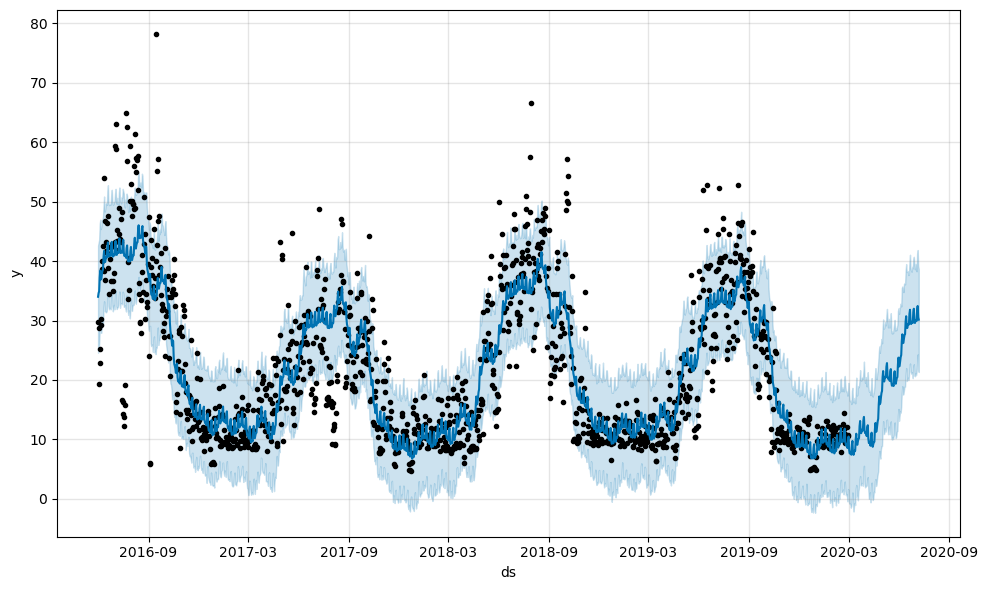

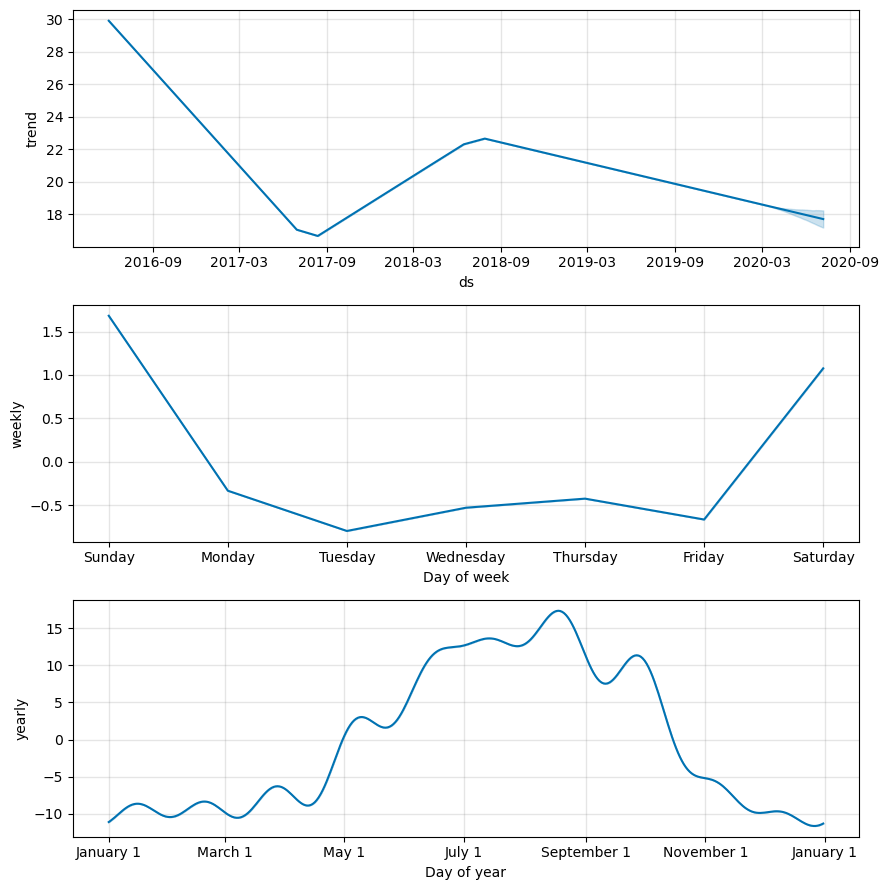

In [122]:
#----------------3-------------
#Grafique las predicciones y las componentes del modelo Prophet.
fig = m.plot(forecast)

fig_components = m.plot_components(forecast)

In [123]:
#------------4---------
#Calcule el MAE de la predicción en el conjunto de entrenamiento y de prueba.
from sklearn.metrics import mean_absolute_error

#tomamos las predicciones del conjunto de prueba
test_forecast = forecast[-len(test_df):]

#  MAE
mae_train = mean_absolute_error(train_df['y'], forecast['yhat'][:len(train_df)])
mae_test = mean_absolute_error(test_df['y'], test_forecast['yhat'])

print(f"MAE - Entrenamiento: {mae_train}")
print(f"MAE - Prueba: {mae_test}")

MAE - Entrenamiento: 4.8174810177174425
MAE - Prueba: 4.921079315201517


In [124]:
import plotly.graph_objects as go

#---------------------5--------------
#Grafique el error (Valor real - Valor predicho) en todo el intervalo de tiempo.
train_error = train_df['y'] - forecast['yhat'][:len(train_df)]
test_error = test_df['y'] - test_forecast['yhat']

# Graficar el error
fig = go.Figure()
fig.add_trace(go.Scatter(x=train_df['ds'], y=train_error, mode='lines', name='Error Entrenamiento'))
fig.add_trace(go.Scatter(x=test_df['ds'], y=test_error, mode='lines', name='Error Prueba'))
fig.update_layout(title='Error del Modelo (Valor Real - Valor Predicho)', xaxis_title='Fecha', yaxis_title='Error')
fig.show()

## 1.4 Incluyendo Regresores [5 puntos]

<center>
<img src ="https://i.redd.it/64hwjftunjjd1.gif" width = 400 />

Con los nuevos resultados obtenidos del modelo Prophet, usted le aconseja a Homero que puede mejorar sus predicciones al incluir regresores en el modelo, es decir, variables adicionales que pueden influir en la variable objetivo, en este caso, el consumo energético. Homero encuentra que es una buena idea y va en busca de ayuda donde el Profesor Frink, un destacado Científico de Springfield. Para suerte de Homero, Frink tenía un estudio reciente que registra las condiciones climáticas en Springfield, en el mismo intervalo de tiempo en que Homero disponía de los datos de consumo eléctrico. Con esta nueva información, usted le recomienda a Homero que podrían utilizar esta información meteorológica proporcionada como variables exógenas al modelo.

Sin embargo, al no comprender bien la importancia de los regresores, Homero decide confiar en sus capacidades y le pide que, por favor, incluya estas variables en el modelo para evaluar su impacto en las predicciones.

Para ello, usted debe:
0. Seleccionar las variables exógenas a utilizar del archivo `datos_frink.csv`. Añada estas variables a sus conjuntos de entrenamiento y prueba mediante `merge`. [0 puntos]
1. Cree el modelo Prophet e incluya los regresores (variables exógenas) al modelo. Luego realice el entrenamiento. **Hint**: Utilice el método `.add_regressor()`. Mas información en el siguiente [Enlace](https://facebook.github.io/prophet/docs/seasonality,_holiday_effects,_and_regressors.html#additional-regressors). [2 puntos]
2. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
3. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. Analice sus resultados. [1 punto]
4. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y de prueba. ¿Hay un comportamiento estacional en la serie? ¿Influyen estas variables en el comportamiento del consumo energético en el hogar de Homero? [1 punto]

Los datos del dataset de Frink son los siguientes:

* **date**: Fecha de medición.
* **Temp_max**: Temperatura máxima registrada durante el día (en °F).
* **Temp_avg**: Temperatura promedio registrada durante el día (en °F).
* **Temp_min**: Temperatura mínima registrada durante el día (en °F).
* **Dew_max**: Punto de rocío máximo registrado durante el día (en °F).
* **Dew_avg**: Punto de rocío promedio registrado durante el día (en °F).
* **Dew_min**: Punto de rocío mínimo registrado durante el día (en °F).
* **Hum_max**: Humedad máxima registrada durante el día (en porcentaje).
* **Hum_avg**: Humedad promedio registrada durante el día (en porcentaje).
* **Hum_min**: Humedad mínima registrada durante el día (en porcentaje).
* **Wind_max**: Velocidad máxima del viento registrada durante el día (en millas por hora, mph).
* **Wind_avg**: Velocidad promedio del viento registrada durante el día (en millas por hora, mph).
* **Wind_min**: Velocidad mínima del viento registrada durante el día (en millas por hora, mph).
* **Press_max**: Presión atmosférica máxima registrada durante el día (en pulgadas de mercurio, Hg).
* **Press_avg**: Presión atmosférica promedio registrada durante el día (en pulgadas de mercurio, Hg).
* **Press_min**: Presión atmosférica mínima registrada durante el día (en pulgadas de mercurio, Hg).

**Respuesta:**

In [126]:
#importamos el dataset
frink = pd.read_csv("datos_frink.csv")

frink['date'] = pd.to_datetime(frink['date'])

frink.head()

,date,Temp_max,Temp_avg,Temp_min,Dew_max,Dew_avg,Dew_min,Hum_max,Hum_avg,Hum_min,Wind_max,Wind_avg,Wind_min,Press_max,Press_avg,Press_min
0,2016-06-01,85,74.8,68,74,71.4,66,100,89.4,65,21,9.5,0,29.8,29.8,29.7
1,2016-06-02,76,71.2,66,74,70.3,66,100,96.8,89,18,7.8,0,29.8,29.8,29.7
2,2016-06-03,79,72.1,68,72,70.0,68,100,93.6,72,18,4.7,0,29.8,29.8,29.7
3,2016-06-04,76,71.2,69,73,70.0,66,100,96.1,85,20,7.0,0,29.8,29.7,29.7
4,2016-06-05,82,73.8,68,72,70.0,68,100,88.7,62,17,7.7,0,29.7,29.7,29.7


In [127]:
#------0----- conjunto de entrenamiento y prueba
train_dff = df[df['date'] <= '2020-02-29']
test_dff = df[df['date'] >= '2020-03-01']

#añadimos las variables exogenas al conj de entrnamiento
train_df2 = pd.merge(train_dff, frink, how='left', on='date')
test_df2 = pd.merge(test_dff, frink, how='left', on='date')

# Extraer variables de entrenamiento y prueba
X_train2 = train_df2[['date']]
y_train2 = train_df2['Energy_kWh']

X_test2 = test_df2[['date']]
y_test2 = test_df2['Energy_kWh']

In [128]:
#------------1------ Prophet
train_df2 = train_df2.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})
test_df2 = test_df2.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})

#modelo Prophet
m2 = Prophet()

# Añadir los regresores
regresores = ['Temp_avg', 'Press_avg']
for reg in regresores:
    m2.add_regressor(reg)

# Entrenar
m2.fit(train_df2)

23:45:57 - cmdstanpy - INFO - Chain [1] start processing
23:45:57 - cmdstanpy - INFO - Chain [1] done processing


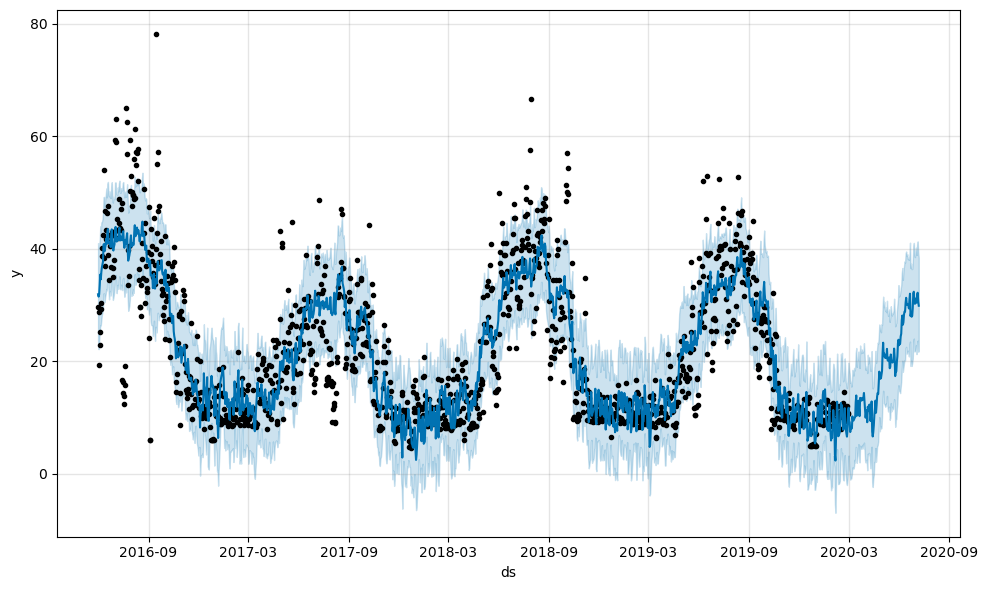

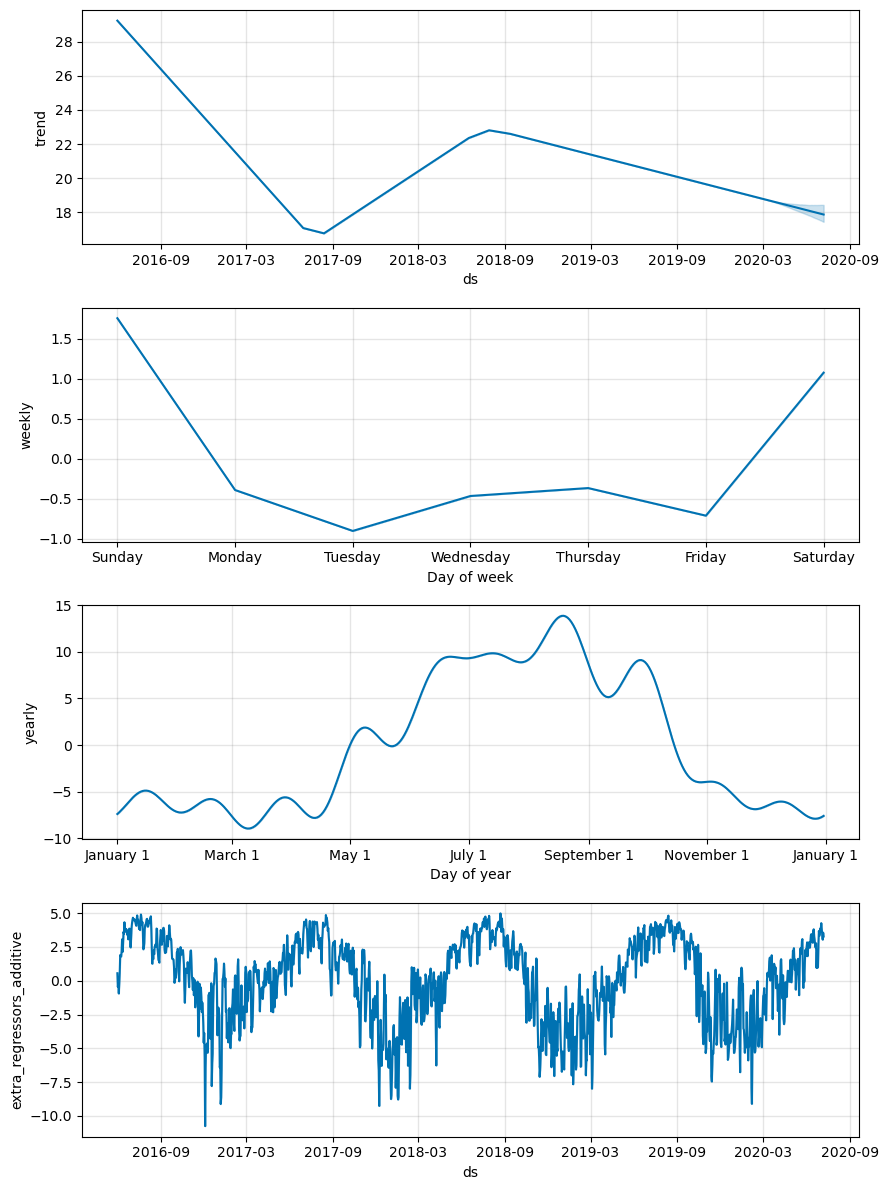

In [129]:
#-----------2------
#df futuro
future = m2.make_future_dataframe(periods=len(test_df2), freq='D')

#merge
future = pd.merge(future, frink, how='left', left_on='ds', right_on='date')

#predicciones
forecast = m2.predict(future)

# Graficar las predicciones
fig = m2.plot(forecast)
fig_components = m2.plot_components(forecast)


In [130]:
#------------3-------------
# Predicciones para el conjunto de prueba
test_forecast = forecast[-len(test_df2):]  # Extraer las predicciones del conjunto de prueba

# Calcular el MAE para el conjunto de entrenamiento y prueba
mae_train = mean_absolute_error(train_df2['y'], forecast['yhat'][:len(train_df2)])
mae_test = mean_absolute_error(test_df2['y'], test_forecast['yhat'])

print(f"MAE - Entrenamiento: {mae_train}")
print(f"MAE - Prueba: {mae_test}")

MAE - Entrenamiento: 4.778739664001653
MAE - Prueba: 4.436958121741565


REspuesta La diferencia entre los errores del conjunto de entrenamiento y de prueba es bastante pequeña, lo que puede indicar que el modello está generalizando bien. Dado que el MAE es bajo y similar en ambos conjuntos, y menos a los obtenidos en las preguntas anteriores, nos dice que la inclusión de los regresores exógenos están mejorando el desempeño del modelo.

In [131]:
#---------------4--------------------
train_error = train_df['y'] - forecast['yhat'][:len(train_df)]
test_error = test_df['y'] - test_forecast['yhat']

# Graficar el error
fig = go.Figure()
fig.add_trace(go.Scatter(x=train_df['ds'], y=train_error, mode='lines', name='Error Entrenamiento'))
fig.add_trace(go.Scatter(x=test_df['ds'], y=test_error, mode='lines', name='Error Prueba'))
fig.update_layout(title='Error del Modelo con Regresores (Valor Real - Valor Predicho)', xaxis_title='Fecha', yaxis_title='Error')
fig.show()

## 1.5 Aplicando Lags [7 puntos]

<center>
<img src ="https://i.gifer.com/J45h.gif" width = 400 />

Homero, satisfecho con los resultados obtenidos, cree que aún puede mejorar el rendimiento del modelo incorporando lags de las variables exógenas. Se le ocurre que, al incluir estos lags, podría identificar cómo los valores pasados de las variables influyen en la evolución de la variable objetivo. Con esta idea en mente, Homero solicita su ayuda para encontrar y aplicar los lags adecuados a las variables exógenas de manera efectiva.

Para ello, a usted se le pide que:

1. Calcule la `Autocorrelación Parcial` de las variables exógenas `avg` que usted haya considerado. Por ejemplo: `Temp_avg, Dew_avg, etc`. Luego determine la cantidad de rezagos (lags) que se va a aplicar a cada una de las variables. Justifique. [1 punto]

2. Aplique los lags determinados en el paso anterior e incluyalos como variables en los conjuntos train y test. [1 punto]

3. Impute los valores nulos de los nuevos atributos lags mediante la media de cada variable. [1 punto]

4. Cree y entrene el modelo Prophet e incluya las variables exógenas y adicionalmente sus respectivos lags al modelo. [1 punto]

5. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
6. Calcule el `MAE` de la predicción en el conjunto de prueba y en el de entrenamiento. Analice sus resultados. [1 punto]
7. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y en el de prueba. ¿Hay un comportamiento estacional en la serie? ¿Como afecta la inclusión de los lags en el desempeño del modelo? [1 punto]


**Respuesta:**

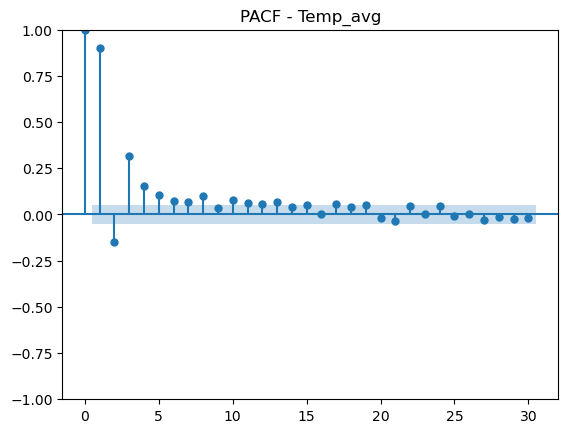

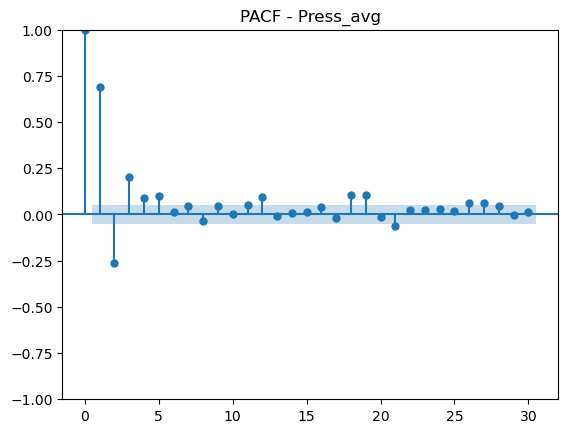

In [133]:
#------------------1-------------- Autocorrelación parcial
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt


variables_exogenas = ['Temp_avg', 'Press_avg']
for var in variables_exogenas:
    plot_pacf(train_df2[var], lags=30, method='ywm')
    plt.title(f'PACF - {var}')
    plt.show()

Vemos que los primeros dos son significativos

In [134]:
#------------------2------------ Aplicar lags
for lag in range(1, 2):
    for var in variables_exogenas:
        train_df2[f'{var}_lag{lag}'] = train_df2[var].shift(lag)
        test_df2[f'{var}_lag{lag}'] = test_df2[var].shift(lag)

In [135]:
#---------------------3--------- Imputar nulos
import pandas as pd
from sklearn.preprocessing import FunctionTransformer

# Definir la función que genera los lags y rolling mean
def get_lags(X):
    '''
    Retorna variables temporales basadas en lags y media móvil.
    '''
    lag_features = pd.DataFrame(index=X.index)
    lag_features['lag_1'] = X.shift(1)  # lag 1 de la serie
    lag_features['rolling_3'] = X.rolling(3).mean()  # media móvil últimos 3 días

    # Imputar valores nulos con la media de cada columna
    lag_features['lag_1'].fillna(lag_features['lag_1'].mean(), inplace=True)
    lag_features['rolling_3'].fillna(lag_features['rolling_3'].mean(), inplace=True)

    return lag_features[['lag_1', 'rolling_3']]

# Crear el transformer
LagsTransformer = FunctionTransformer(get_lags)

# Aplicar el transformer a los datos de prueba
lagged_X_test = LagsTransformer.transform(X_test2['Temp_avg'])

# Si necesitas aplicar también a los datos de entrenamiento:
lagged_X_train = LagsTransformer.transform(X_train2['Temp_avg'])

# Visualizar los primeros valores
print(lagged_X_test.head())

KeyError: 'Temp_avg'

## 1.6 Optimizando Prophet [6 puntos]

<center>
<img src ="https://i.gifer.com/BKlg.gif" width = 500 />

Homero, contento con sus resultados, decide compartir su trabajo en LinkedIn. Sin embargo, justo antes de realizar la publicación, su hija Lisa Simpson le comenta que su modelo podría mejorar aún más mediante la optimización de hiperparámetros. Aunque Homero no entiende muy bien a qué se refiere Lisa, decide confiar en su conocimiento y le pide ayuda para implementar la optimización.

Lisa le prepara una función llamada optimize_prophet, que recibe como entrada el registro histórico, los datos a predecir (futuros), el nombre de las variables exógenas y una grilla de hiperparámetros que se desea modificar.

Después de varios intentos, Homero no logra utilizar la función de Lisa y, desesperado por publicar sus resultados en internet, se acerca a usted en busca de ayuda.

Para ello, usted decide realizar los siguientes pasos:

1. Crear una grilla donde se modifiquen los siguientes hiperparámetros: `changepoint_prior_scale`, `seasonality_prior_scale`, `seasonality_mode`, `changepoint_range` y encuentre los hiperparámetros que optimicen el `MAE`. `Nota:` Utilice la función `optimize_prophet()` dada en el enunciado. [1 punto]
2. Crear y entrenar un modelo Prophet utilizando los mejores parámetros encontrados, incluyendo regresores (variables exógenas). [2 puntos]
3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y en el de prueba. [1 punto]
5. Grafique el error (Valor real - Valor predicho) en ambos conjuntos. Analice sus resultados. [1 punto]


In [ ]:
#NO MODIFICAR ESTA CELDA

import itertools
import numpy as np
import pandas as pd
from tqdm import tqdm
import logging

# Silenciar el logging de Prophet
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)


def optimize_prophet(df, df_to_pred, features, param_grid ):
  '''
  Función que recibe como entrada:
  -df: data entrenamiento.
  -df_to_pred: data a predecir (test).
  -features: lista de variables exógenas.
  -param_grid: grilla de hiperparámetros.

  Retorna:
  -tuning_results: Dataframe con resultados de la optimización.
  -best_params: Diccionario de mejores parámetros encontrados.
  '''

  # Generate all combinations of parameters
  all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
  MAEs = []  # Store the MAEs for each params here

  # Use tqdm to add a progress bar to the parameter tuning loop
  for params in tqdm(all_params, desc="Tuning Prophet parameters"):
      m = Prophet(**params)  # Fit model with given params
      for feature in features:
          m.add_regressor(feature)
      m.fit(df)

      # Prepare future dataframe
      df_prop = m.make_future_dataframe(periods=len(df_to_pred))
      df_feat = pd.concat([df[features], df_to_pred[features]]).reset_index(drop=True)
      df_prop[features] = df_feat[features]

      # Make predictions
      forecast = m.predict(df_prop)
      forecast_pred = forecast[forecast['ds'].isin(df_to_pred['ds'])].reset_index(drop=True)

      # Calculate MAE for the predictions
      mae_pred = mean_absolute_error(df_to_pred['y'], forecast_pred['yhat'])
      MAEs.append(mae_pred)

  # Find the best parameters
  tuning_results = pd.DataFrame(all_params)
  tuning_results['MAEs'] = MAEs
  tuning_results = tuning_results.sort_values(by='MAEs', ascending=True)
  best_params = all_params[np.argmin(MAEs)]
  return tuning_results, best_params

**Respuesta:**

In [ ]:
#CODIGO AQUI

# **2. Sistemas de Recomendación (30 puntos)**

## Homero contra la Prohibición

<center>
<img src ="https://i.ytimg.com/vi/rMSXXuhZjYY/maxresdefault.jpg" width = 500 />

En Springfield, el caos estalló cuando las autoridades prohibieron el alcohol. Pero como siempre, donde otros ven problemas, Homero Simpson ve oportunidades. Decidido a mantener las fiestas vivas, se convirtió en el Barón de la Cerveza en un abrir y cerrar de ojos. Con la ayuda de su buen amigo Moe el cantinero, Homero obtuvo un valioso dataset llamado `cervezas.csv`, que contiene valoraciones de los ciudadanos de Springfield sobre distintas cervezas. Homero quiere asegurarse de ofrecer las cervezas más apreciadas para mantener a su clientela oculta y feliz, mientras eludía la mirada del estricto Elio Pez. Por ende, Homero lo contacta para solicitar de su ayuda en esta nueva labor.

El dataset contiene los siguientes atributos:

  * userId: Identificador de los ciudadanos/usuarios
  * beerId: Identificador único de cada cerveza
  * rating: Evaluación otorgada por el ciudadano a la cerveza, en un rango de 1.0 a 5.0.
  * beerName: Nombre de la cerveza
  * beerStyle: Tipo de Cerveza.



In [9]:
!pip install surprise

  Using cached surprise-0.1-py2.py3-none-any.whl.metadata (327 bytes)
  Using cached scikit_surprise-1.1.4.tar.gz (154 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using cached surprise-0.1-py2.py3-none-any.whl (1.8 kB)
  error: subprocess-exited-with-error
  
  × Building wheel for scikit-surprise (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [71 lines of output]
      running bdist_wheel
      running build
      running build_py
      creating build/lib.linux-x86_64-cpython-312/surprise
      copying surprise/dataset.py -> build/lib.linux-x86_64-cpython-312/surprise
      copying surprise/__main__.py -> build/lib.linux-x86_64-cpython-312/surprise
      copying surprise/utils.py -> build/lib.linux-x86_64-cpython-312/surprise
      copying surprise/__init__.py -> build/lib.linux-x86_64-cpython-312/surprise
      copying surprise/dump.py -> build/lib.linux-x86_64-cpython-31

In [20]:
# Librerias extras
from sklearn.preprocessing import LabelEncoder

from surprise import accuracy
from surprise.reader import Reader
from surprise.dataset import Dataset
from surprise.prediction_algorithms.knns import KNNBasic
from surprise.prediction_algorithms.matrix_factorization import SVD
from surprise.accuracy import mae
from surprise import NMF
from collections import defaultdict
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import pandas as pd
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Carga de los datos [0 puntos]

Cargue el dataset `cervezas.csv` y realice una breve exploración de los datos. ¿Hay valores nulos? ¿Cuantos cervezas se estan evaluando? ¿Cuantos ciudadanos participaron de esta evaluación?

In [11]:
import pandas as pd

data = pd.read_csv('cervezas.csv')

# Verificar si hay valores nulos
valores_nulos = data.isnull().sum()

cervezas_unicas = data['beerId'].nunique()
ciudadanos_unicos = data['userId'].nunique()

#Imprimir 
print("Valores nulos:\n", valores_nulos)
print("\nNúmero de cervezas evaluadas:", cervezas_unicas)
print("Número de ciudadanos que participaron:", ciudadanos_unicos)


Valores nulos en cada columna:
 userId       0
beerId       0
rating       0
beerName     0
beerStyle    0
dtype: int64

Número de cervezas evaluadas: 3747
Número de ciudadanos que participaron: 706


In [12]:
data

,userId,beerId,rating,beerName,beerStyle
0,144,995,3.0,Mai Bock,Maibock / Helles Bock
1,63,58695,4.0,Hop In The Dark Cascadian Dark Ale,American Black Ale
2,147,4083,5.0,Stone Ruination IPA,American Double / Imperial IPA
3,4261,40310,3.0,Noël Des Géants,Herbed / Spiced Beer
4,140,1904,5.0,Sierra Nevada Celebration Ale,American IPA
...,...,...,...,...,...
295054,863,45653,4.0,Consecration,American Wild Ale
295055,306,1341,4.0,Keystone Light,Light Lager
295056,8,8917,3.0,Drop Top Amber,American Amber / Red Ale
295057,35,102,3.0,Samuel Adams Octoberfest,Märzen / Oktoberfest


## 2.1 Caracterización Inicial [3 puntos]

Antes de entrenar nuestro sistema recomendador, es necesario caracterizar los datos disponibles y de esta manera tener un mejor entendimiento del problema a resolver. Para esto, se le pide lo siguiente:

1. Genere gráficos y/o estadística descriptiva con los datos. Utilice su análisis para responder las siguientes preguntas: [2 puntos]
  - ¿Cuantos *usuarios* hay en los datos?
  - ¿Cuantos *productos* hay en los datos?
  - ¿Cuantas *calificaciones* hay en los datos?
  - ¿Cuantas *calificaciones* faltantes hay en los datos?
  - ¿Cual es la media de las *calificaciones* entregadas por los usuarios? ¿Cómo cambia esto a través de los productos?  
2. Transforme los datos entregados a una matriz (usuario, producto) y muestre sus resultados. [1 punto]

In [13]:
#explorar los datos
print(data.info()) 
print(data.describe())  #

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295059 entries, 0 to 295058
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     295059 non-null  int64  
 1   beerId     295059 non-null  int64  
 2   rating     295059 non-null  float64
 3   beerName   295059 non-null  object 
 4   beerStyle  295059 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 11.3+ MB
None
              userId         beerId         rating
count  295059.000000  295059.000000  295059.000000
mean     2201.510247   17498.665684       3.860367
std      4577.423286   19971.480254       0.702807
min         1.000000       5.000000       1.000000
25%       132.000000    1185.000000       3.500000
50%       293.000000    6314.000000       4.000000
75%      1141.000000   33639.000000       4.500000
max     27681.000000   75086.000000       5.000000


In [14]:
num_usuarios = data['userId'].nunique()
print("Número de usuarios únicos:", num_usuarios)


Número de usuarios únicos: 706


In [23]:
num_productos = data['beerId'].nunique()
print("Número de cervezas únicas:", num_productos)


Número de cervezas únicas: 3747


In [16]:
num_calificaciones = len(data)
print("Número de calificaciones registradas:", num_calificaciones)


Número de calificaciones registradas: 295059


In [17]:
calificaciones_faltantes = data['rating'].isnull().sum()
print("Número de calificaciones faltantes:", calificaciones_faltantes)


Número de calificaciones faltantes: 0


In [18]:
media_calificaciones = data['rating'].mean()
print("Media de las calificaciones:", media_calificaciones)


Media de las calificaciones: 3.8603669096689135


Media de calificaciones por producto:
 beerId
5        3.395000
6        3.765217
7        3.256849
9        3.478261
10       3.791908
           ...   
74827    4.100000
74904    3.896552
74986    4.274336
75013    4.242424
75086    3.753247
Name: rating, Length: 3747, dtype: float64


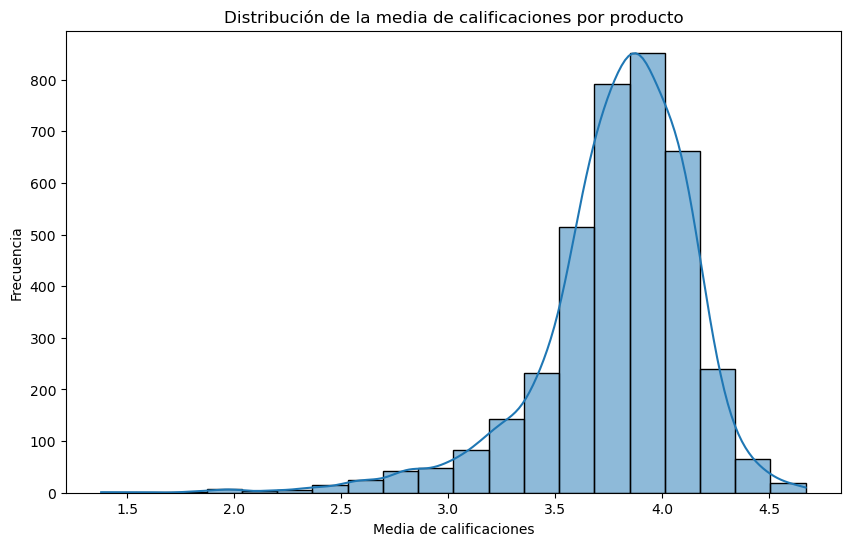

In [21]:
media_calificaciones_por_producto = data.groupby('beerId')['rating'].mean()
print("Media de calificaciones por producto:\n", media_calificaciones_por_producto)

# Visualizar la distribución de las calificaciones por producto
plt.figure(figsize=(10, 6))
sns.histplot(media_calificaciones_por_producto, bins=20, kde=True)
plt.title("Distribución de la media de calificaciones por producto")
plt.xlabel("Media de calificaciones")
plt.ylabel("Frecuencia")
plt.show()


In [24]:

num_estilos = data['beerStyle'].nunique()
print("Número de estilos de cerveza únicos:", num_estilos)

# Ver los diferentes estilos de cerveza
print(data['beerStyle'].unique())


Número de estilos de cerveza únicos: 101
['Maibock / Helles Bock' 'American Black Ale'
 'American Double / Imperial IPA' 'Herbed / Spiced Beer' 'American IPA'
 'German Pilsener' 'Old Ale' 'English Barleywine' 'Bock' 'Winter Warmer'
 'Saison / Farmhouse Ale' 'Scottish Gruit / Ancient Herbed Ale' 'Dubbel'
 'Extra Special / Strong Bitter (ESB)' 'English Pale Ale'
 'American Strong Ale' 'English Bitter' 'English India Pale Ale (IPA)'
 'Russian Imperial Stout' 'Lambic - Fruit' 'English Brown Ale'
 'Hefeweizen' 'Witbier' 'Tripel' 'American Adjunct Lager'
 'Belgian Strong Pale Ale' 'American Barleywine' 'American Pale Ale (APA)'
 'Light Lager' 'American Porter' 'Oatmeal Stout' 'Doppelbock'
 'Vienna Lager' 'Scotch Ale / Wee Heavy' 'Dunkelweizen'
 'American Amber / Red Lager' 'American Blonde Ale'
 'American Amber / Red Ale' 'Baltic Porter' 'Quadrupel (Quad)'
 'Pumpkin Ale' 'American Pale Wheat Ale' 'Fruit / Vegetable Beer'
 'Schwarzbier' 'Chile Beer' 'Gueuze' 'Irish Dry Stout'
 'Belgian Strong

In [25]:
media_rating_por_estilo = data.groupby('beerStyle')['rating'].mean().sort_values(ascending=False)
print("Media de calificaciones por estilo de cerveza:\n", media_rating_por_estilo)


Media de calificaciones por estilo de cerveza:
 beerStyle
American Wild Ale                   4.131725
Gose                                4.116162
Quadrupel (Quad)                    4.097011
Gueuze                              4.083260
American Double / Imperial Stout    4.053046
                                      ...   
American Adjunct Lager              3.049920
Euro Strong Lager                   2.863793
American Malt Liquor                2.820138
Light Lager                         2.653801
Low Alcohol Beer                    2.523438
Name: rating, Length: 101, dtype: float64


/tmp/ipykernel_54842/3606513174.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rating', y='beerStyle', data=data, palette='Set2')


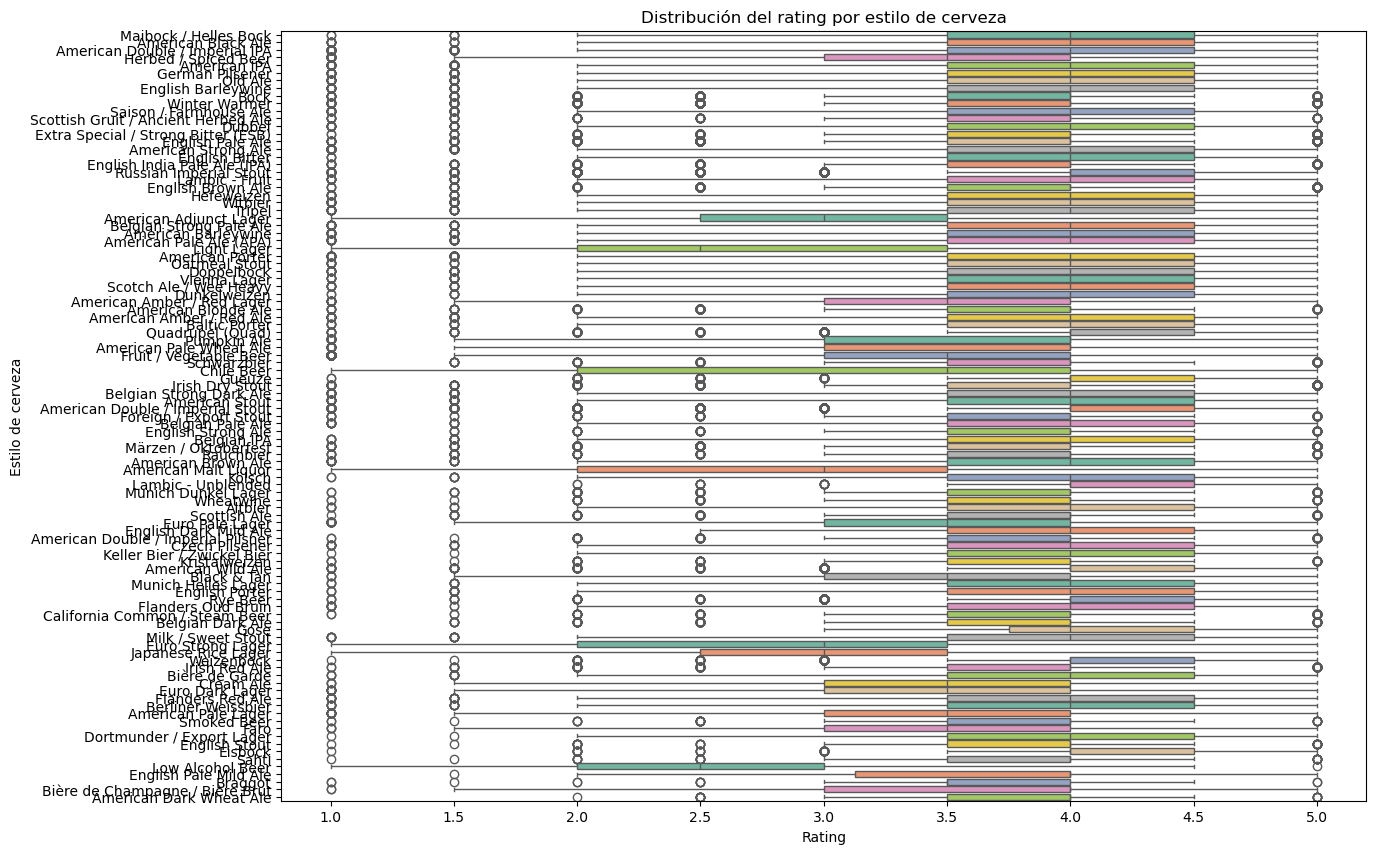

In [26]:
plt.figure(figsize=(14, 10))
sns.boxplot(x='rating', y='beerStyle', data=data, palette='Set2')
plt.title("Distribución del rating por estilo de cerveza")
plt.xlabel("Rating")
plt.ylabel("Estilo de cerveza")
plt.show()


In [136]:
# Crear la matriz 
matriz_usuario_producto = data.pivot_table(index='userId', columns='beerId', values='rating')

# Mostrar la matriz resultante
print(matriz_usuario_producto)
print("Dimensiones de la matriz (usuarios, productos):", matriz_usuario_producto.shape)



beerId  5      6      7      9      10     11     14     15     17     19     \
userId                                                                         
1         NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
3         1.0    5.0    3.5    3.5    NaN    NaN    NaN    NaN    NaN    NaN   
4         NaN    NaN    NaN    NaN    4.0    NaN    NaN    NaN    NaN    NaN   
5         NaN    NaN    NaN    NaN    NaN    4.0    NaN    NaN    NaN    NaN   
6         NaN    NaN    NaN    NaN    NaN    NaN    4.0    NaN    NaN    NaN   
...       ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
24903     NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
25317     NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
25923     NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
27039     NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
27681     NaN    NaN    NaN    NaN    Na

## 2.2 Método Basado en Contenido [4 puntos]

<center>
<img src ="https://is1-ssl.mzstatic.com/image/thumb/WfNa_TwFpJoTWXQmU-BrbA/1200x675.jpg" width = 500 />

Como primera tarea, Homero le pide centrarse en las características de las cervezas y no en la interacción de los ciudadanos con esta. Adicionalmente, Homero esta buscando nuevas cervezas para su consumo personal, donde usted pudo notar que Homero esta identificado como `userId = 100` en el dataset. Por ende, Homero le pide las siguientes acciones:

1. Cree un dataframe que contenga las características de las cervezas, excluyendo las evaluaciones de los ciudadanos. `Nota:` No considere valores duplicados. [1 punto]
2. Implemente el método Bag of Words para procesar la columna `beerStyle`. Para ello, transforme las palabras a minúsculas, elimine stopwords en inglés y filtre las palabras que aparezcan en 10 documentos como mínimo. Guarde su resultado como un DataFrame. [1 punto].
> `Nota:` Le puede ser útil esta [documentacion](https://scikit-learn.org/1.5/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) y el método `.get_feature_names_out()`.
3. Cree una función que imprima las top 5 cervezas similares a `Chocolate Porter`, utilizando como medida de similitud la similitud coseno. [1 punto]
4. Identifique la cerveza mejor evaluada por Homero (`userId = 100`) y obtenga las top 5 cervezas similares a esa cerveza. [1 punto]

**Respuesta:**

In [66]:

df_beers = data[['beerId', 'beerName', 'beerStyle']].drop_duplicates().reset_index(drop=True)

df_beers

,beerId,beerName,beerStyle
0,995,Mai Bock,Maibock / Helles Bock
1,58695,Hop In The Dark Cascadian Dark Ale,American Black Ale
2,4083,Stone Ruination IPA,American Double / Imperial IPA
3,40310,Noël Des Géants,Herbed / Spiced Beer
4,1904,Sierra Nevada Celebration Ale,American IPA
...,...,...,...
3742,47589,Red,American Amber / Red Ale
3743,62792,Splinter Black,American Double / Imperial Stout
3744,18432,Wittekerke Rosé,Fruit / Vegetable Beer
3745,4753,Hambleton Nightmare (Extra Stout Porter),English Porter


In [67]:
from sklearn.feature_extraction.text import CountVectorizer


vectorizer = CountVectorizer(lowercase=True, stop_words='english', min_df=10)

bow = vectorizer.fit_transform(df_beers['beerStyle']).toarray()

df_bow = pd.DataFrame(bow, columns=vectorizer.get_feature_names_out())


In [68]:
df_bow

,adjunct,ale,altbier,amber,american,apa,baltic,barleywine,beer,belgian,...,vienna,warmer,wee,weizenbock,wheat,wheatwine,wild,winter,witbier,zwickel
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3742,0,1,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3743,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3744,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3745,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [69]:

from sklearn.metrics.pairwise import cosine_similarity

# calculamos la similitud coseno de cada vector generado contra el resto
cosine_sim = cosine_similarity(df_bow, df_bow)
cosine_sim.shape

(3747, 3747)

In [70]:
def get_recommendations(df, beer_name, k=5):
    """
    devuelve el top k de recomendacioens
    """
    if beer_name not in df['beerName'].values:
        print(f"La cerveza '{beer_name}' no se encuentra en el DataFrame de cervezas.")
        return None

    idx = df[df['beerName'] == beer_name].index[0]

    sim_scores = list(enumerate(cosine_sim[idx]))

    # Ordenar cervezas basándose en las puntuaciones de similitud
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:k+1]  # Excluyendo la cerveza misma
    beer_indices = [i[0] for i in sim_scores]

    return df['beerName'].iloc[beer_indices].values

In [71]:
# mejor calificación de Homero
userId=100
homero_best_rating = data[data['userId']==userId].sort_values('rating', ascending=False)
best_beer_name = homero_best_rating.iloc[0]['beerName']
print(f'most liked beer by user {userId}: {best_beer_name}')

# top 5 cervezas similares a la mejor calificación de Homero
similar_beers_to_best = get_recommendations(df_beers, best_beer_name)
print(similar_beers_to_best)


most liked movie by user 100: McNeill's Firehouse Amber Ale
['Grail Ale' "Santa's Private Reserve Ale" 'Hemp Hop Rye Amber Ale'
 'Autumn Fest' 'Red Rocket Ale']


In [73]:
print(f"Tamaño de df_beers: {df_beers.shape[0]}")
print(f"Tamaño de cosine_sim: {cosine_sim.shape[0]}")


Tamaño de df_beers: 3747
Tamaño de cosine_sim: 3747


## 2.3 Filtros Colaborativos [16 puntos]

<center>
<img src ="https://i.makeagif.com/media/2-08-2016/McmGFQ.gif" width = 400 />

Después de consolidarse como el Barón de la Cerveza en Springfield, Homero Simpson decidió llevar su negocio clandestino a otro nivel. Al ser el único proveedor de alcohol en la ciudad, quiere asegurarse de que cada cerveza que elabora sea de la mejor calidad posible. Para lograrlo, planea usar las evaluaciones pasadas que los ciudadanos de Springfield han registrado sobre las distintas cervezas. Inspirado por los consejos de su amigo Moe, Homero se enteró de que puede implementar un sistema de recomendación basado en filtros colaborativos.

Ahora, Homero necesita de su ayuda para diseñar y elaborar distintos sistemas de filtros colaborativos que le permitan continuar con su reinado cervecero.

### 2.3.1 Filtros Colaborativos Basados en Memoria [8 puntos]

Para este tipo de filtros, Homero le pide lo siguiente:

1. Transforme el DataFrame de `pandas` a Dataset de `surprise`. `Hint`: Utilice solamente los identificadores de ciudadano, cerveza y rating. ¿Importa el orden? [1 punto]
2. Genere un conjunto de entrenamiento y uno de prueba, asegurando que el 30% de los datos sea destinado al conjunto de prueba. No olvide fijar una semilla para garantizar reproducibilidad. [1 punto]
3. Entrene un modelo de **KNN basado en usuarios** utilizando la `similitud coseno`. Luego realice predicciones en el conjunto de prueba. `Nota`: Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/knn_inspired.html) [2 puntos]
4. Calcule el MAE (Mean Absolute Error) de las predicciones realizadas por el modelo y muestre las predicciones en un DataFrame para su análisis. `Nota:` Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/accuracy.html#surprise.accuracy.mae) [2 puntos]
5. Repita los pasos 3 y 4 pero utilizando un modelo de **KNN basado en los productos**. [2 puntos]

**Respuesta:**

In [74]:
from surprise import Dataset
from surprise import Reader

ratings = data[['userId', 'beerId', 'rating']]

reader = Reader(rating_scale=(ratings['rating'].min(), ratings['rating'].max()))

data_surprise = Dataset.load_from_df(ratings[['userId', 'beerId', 'rating']], reader)


In [75]:
from surprise.model_selection import train_test_split

random_state = 42
trainset, testset = train_test_split(data_surprise, test_size=0.3, random_state=random_state)


In [76]:
from surprise import KNNBasic

sim_options = {
    'name': 'cosine',
    'user_based': True 
}

algo_user = KNNBasic(sim_options=sim_options)

algo_user.fit(trainset)

predictions_user = algo_user.test(testset)


Computing the cosine similarity matrix...
Done computing similarity matrix.


In [77]:
from surprise import accuracy

mae_user = accuracy.mae(predictions_user)

predicciones_df = pd.DataFrame([(pred.uid, pred.iid, pred.r_ui, pred.est) for pred in predictions_user],
                               columns=['userId', 'beerId', 'rating_real', 'rating_predicho'])
print(predicciones_df.head())


MAE:  0.4639
   userId  beerId  rating_real  rating_predicho
0    1628    9755          4.5         4.200000
1     187     601          2.0         3.825000
2     112     409          3.0         3.862500
3     738    5051          4.0         4.027027
4     141    4394          4.0         3.887500


In [78]:

sim_options_item = {
    'name': 'cosine',
    'user_based': False 
}

algo_item = KNNBasic(sim_options=sim_options_item)

algo_item.fit(trainset)

predictions_item = algo_item.test(testset)

mae_item = accuracy.mae(predictions_item)

predicciones_item_df = pd.DataFrame([(pred.uid, pred.iid, pred.r_ui, pred.est) for pred in predictions_item],
                                    columns=['userId', 'beerId', 'rating_real', 'rating_predicho'])
print(predicciones_item_df.head())


Computing the cosine similarity matrix...
Done computing similarity matrix.
MAE:  0.4640
   userId  beerId  rating_real  rating_predicho
0    1628    9755          4.5         4.200000
1     187     601          2.0         3.825000
2     112     409          3.0         3.862500
3     738    5051          4.0         4.000615
4     141    4394          4.0         3.887500


### 2.3.2 Filtros Colaborativos Basados en Modelo [8 puntos]

Ahora Homero le pide que cambie el enfoque del tipo de filtro colaborativo a uno basado en modelo. Por ende, Homero le pide lo siguiente:

1. Entrene un modelo `NMF` , asegurándose de fijar la semilla para reproducibilidad. Luego genere predicciones para el conjunto de prueba. [2 puntos]
2. Calcule el MAE de las predicciones obtenidas y muestre los resultados de las predicciones en un DataFrame para su analisis. [1 punto]
3. Entrene un modelo `SVD` sobre el conjunto de entrenamiento. Posteriormente, genere las predicciones para el conjunto de prueba. [2 puntos]
4. Calcule el MAE de las predicciones y muestre los resultados de las predicciones en un DataFrame. [1 punto]
5. Compare los resultados de ambos modelos y seleccione el mejor a su criterio. Justifique. [2 puntos]

**Respuesta**

In [79]:
from surprise import NMF
from surprise import Dataset, Reader
from surprise.model_selection import train_test_split
from surprise import accuracy

ratings = data[['userId', 'beerId', 'rating']]
reader = Reader(rating_scale=(ratings['rating'].min(), ratings['rating'].max()))
data_surprise = Dataset.load_from_df(ratings[['userId', 'beerId', 'rating']], reader)


random_state = 42
trainset, testset = train_test_split(data_surprise, test_size=0.3, random_state=random_state)

nmf = NMF(random_state=random_state)
nmf.fit(trainset)

# Generar predicciones en el conjunto de prueba
predictions_nmf = nmf.test(testset)


In [80]:

mae_nmf = accuracy.mae(predictions_nmf)

predicciones_nmf_df = pd.DataFrame([(pred.uid, pred.iid, pred.r_ui, pred.est) for pred in predictions_nmf],
                                   columns=['userId', 'beerId', 'rating_real', 'rating_predicho'])
print(predicciones_nmf_df.head())


MAE:  0.4826
   userId  beerId  rating_real  rating_predicho
0    1628    9755          4.5         3.682730
1     187     601          2.0         3.714152
2     112     409          3.0         3.973135
3     738    5051          4.0         3.767895
4     141    4394          4.0         3.910392


In [81]:
from surprise import SVD


svd = SVD(random_state=random_state)
svd.fit(trainset)

predictions_svd = svd.test(testset)


In [82]:

mae_svd = accuracy.mae(predictions_svd)

predicciones_svd_df = pd.DataFrame([(pred.uid, pred.iid, pred.r_ui, pred.est) for pred in predictions_svd],
                                   columns=['userId', 'beerId', 'rating_real', 'rating_predicho'])
print(predicciones_svd_df.head())


MAE:  0.4610
   userId  beerId  rating_real  rating_predicho
0    1628    9755          4.5         4.022229
1     187     601          2.0         3.807105
2     112     409          3.0         3.885699
3     738    5051          4.0         4.014968
4     141    4394          4.0         3.926274


El MAE refleja el error medio absoluto entre las calificaciones reales y predichas. Un menor MAE indica que el modelo predice mejor las calificaciones de los usuarios.

In [83]:
print(f"MAE de NMF: {mae_nmf}")
print(f"MAE de SVD: {mae_svd}")



if mae_nmf < mae_svd:
    print("NMF es el mejor modelo basado en el MAE.")
else:
    print("SVD es el mejor modelo basado en el MAE.")


MAE de NMF: 0.48259310524680443
MAE de SVD: 0.4610339636110489
SVD es el mejor modelo basado en el MAE.


## 2.4 El Mejor Filtro Colaborativo [7 puntos]

<center>
<img src ="https://media.giphy.com/media/citBl9yPwnUOs/giphy.gif" width = 400 />

Homero Simpson desea perfeccionar y extender su sistema de recomendaciones para cervezas en Springfield. En esta fase, busca implementar técnicas que le permitan no solo predecir las preferencias de los ciudadanos, sino también evaluar métricas que midan la eficacia de sus recomendaciones. Con el objetivo de recomendar las mejores K cervezas para usuarios específicos, Homero buscará comprender mejor cómo optimizar su sistema y satisfacer a sus clientes.

Para ello, usted ayudará a Homero realizando las siguientes labores:

1. Implemente la función `get_top_n()` que le permita extraer las `N` mejores cervezas recomendadas para cada ciudadano utilizando las predicciones generadas por el mejor modelo seleccionado en la sección anterior. Luego obtenga las `3` mejores cervezas recomendadas para Homero (`userId = 100`). `Hint`: Para cada ciudadano, elimine las predicciones duplicadas. [2 puntos]
2. Realice predicciones de rating para 5 cervezas aleatorias no evaluadas por Homero, para estimar las calificaciones que Homero podría darles. [1 punto]
3. Calcule los promedios de `precisión@k` y el `recall@k` para `k=10` y `threshold = 3.5`. Analice sus resultados. ¿Es un buen modelo? `Hint:` Utilice la función dada `precision_recall_at_k(...)`. [1 punto]
4. Calcule la `precisión@k` y el `recall@k` para valores de `k` que varíen entre 3 y 25 con paso de 1 unidad. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `k`. [1 punto]
5. Calcule la `precisión@k` y el `recall@k` para valores de `threshold` que varíen entre 3.0 y 4.5, con paso de 0.1. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `threshold`. [1 punto]
6. Finalmente utilice el mejor modelo para estimar los ratings faltantes. Muestre sus resultados en una matriz (usuario, producto) sin valores nulos. [1 punto]



In [90]:
#NO MODIFICAR ESTA CELDA
def precision_recall_at_k(predictions, k=10, threshold=3.5):

    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        n_rel_and_rec_k = sum(
            ((true_r >= threshold) and (est >= threshold))
            for (est, true_r) in user_ratings[:k]
        )
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0
    return precisions, recalls

**Respuesta:**

In [91]:
from collections import defaultdict

def get_top_n_with_names(predictions, df_beers, n=3):
    """
    Retorna las mejores N cervezas recomendadas para cada usuario,
    con los nombres de las cervezas, eliminando las duplicadas.
    """
  
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))

    for uid, user_ratings in top_n.items():
        unique_ratings = {}
        for beer, est in user_ratings:
            if beer not in unique_ratings:
                unique_ratings[beer] = est

        sorted_ratings = sorted(unique_ratings.items(), key=lambda x: x[1], reverse=True)

        top_n[uid] = [(df_beers[df_beers['beerId'] == beer]['beerName'].values[0], est) for beer, est in sorted_ratings[:n]]

    return top_n

# Obtener las top 3 cervezas recomendadas para Homero (userId=100)
top_n_with_names = get_top_n_with_names(predictions_svd, df_beers, n=3)  # Asumiendo que SVD fue el mejor modelo
top_3_homero = top_n_with_names[100]
print("Top 3 cervezas recomendadas para Homero:", top_3_homero)



Top 3 cervezas recomendadas para Homero: [("McNeill's Firehouse Amber Ale", 3.941802288645008), ("McNeill's Extra Special Bitter", 3.926976399705735), ("McNeill's Dead Horse IPA", 3.7638289292285254)]


In [92]:
import random

# Obtener el set de cervezas que Homero ha evaluado
cervezas_homero = data[data['userId'] == 100]['beerId'].values

# Obtener cervezas no evaluadas por Homero
cervezas_no_evaluadas = df_beers[~df_beers['beerId'].isin(cervezas_homero)]['beerId'].values

# Seleccionar 5 cervezas aleatorias no evaluadas por Homero
cervezas_aleatorias = random.sample(list(cervezas_no_evaluadas), 5)

# Predecir las calificaciones para esas 5 cervezas y mostrar los nombres
for cerveza in cervezas_aleatorias:
    pred = svd.predict(100, cerveza)

    nombre_cerveza = df_beers[df_beers['beerId'] == cerveza]['beerName'].values[0]
    
    print(f"Predicción para la cerveza '{nombre_cerveza}': {pred.est}")



Predicción para la cerveza 'Double Dog Double Pale Ale': 3.853625165458775
Predicción para la cerveza 'Unibroue 16': 3.81083456439445
Predicción para la cerveza 'Gouden Carolus Hopsinjoor': 3.8966082638078925
Predicción para la cerveza 'St-Ambroise Oatmeal Stout': 3.863484615911376
Predicción para la cerveza 'Heavy Handed IPA': 3.877097933179973


In [93]:
from collections import defaultdict

precisions, recalls = precision_recall_at_k(predictions_svd, k=10, threshold=3.5)

avg_precision = sum(prec for prec in precisions.values()) / len(precisions)
avg_recall = sum(rec for rec in recalls.values()) / len(recalls)

print(f"Promedio de precisión@10: {avg_precision}")
print(f"Promedio de recall@10: {avg_recall}")


Promedio de precisión@10: 0.7433309726156743
Promedio de recall@10: 0.3398682151789204


El modelo es bueno en términos de precisión, ya que el 74.33% de las cervezas recomendadas en el top-10 son relevantes para los usuarios, lo que significa que hace recomendaciones acertadas. Sin embargo, el recall es más bajo, con un 33.99%, lo que indica que no está capturando todas las cervezas que podrían interesar a los usuarios. En resumen, el modelo es adecuado si se busca priorizar la calidad de las recomendaciones, pero podría mejorarse si se quiere abarcar más cervezas relevantes.

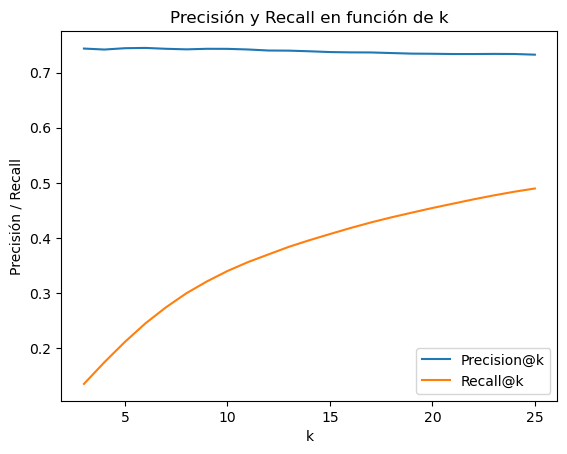

In [94]:
import matplotlib.pyplot as plt

ks = range(3, 26)
precisions_k = []
recalls_k = []

for k in ks:
    precisions, recalls = precision_recall_at_k(predictions_svd, k=k, threshold=3.5)
    avg_precision_k = sum(prec for prec in precisions.values()) / len(precisions)
    avg_recall_k = sum(rec for rec in recalls.values()) / len(recalls)
    precisions_k.append(avg_precision_k)
    recalls_k.append(avg_recall_k)

# Graficar los resultados
plt.plot(ks, precisions_k, label='Precision@k')
plt.plot(ks, recalls_k, label='Recall@k')
plt.xlabel('k')
plt.ylabel('Precisión / Recall')
plt.title('Precisión y Recall en función de k')
plt.legend()
plt.show()


El gráfico muestra cómo varía la precisión y el recall a medida que se incrementa el valor de k. La precisión tiende a disminuir levemente al aumentar k, lo cual es esperado ya que, al incluir más recomendaciones, es probable que se introduzcan elementos menos relevantes, disminuyendo la precisión. Sin embargo, el recall aumenta con k, dado que se consideran más ítems relevantes dentro de las recomendaciones. Este comportamiento es típico en sistemas de recomendación: al aumentar el número de recomendaciones (k), se sacrifica precisión a favor de un mayor recall, lo que refleja una mayor cobertura de ítems relevantes. Este balance entre ambas métricas debe ser considerado al ajustar k según los objetivos del sistema.

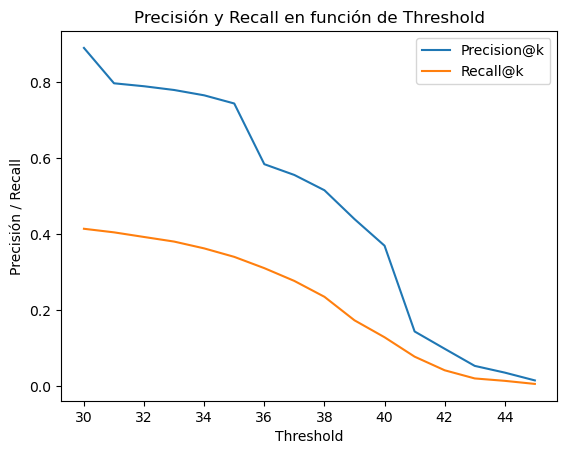

In [95]:
thresholds = [round(x, 1) for x in list(range(30, 46, 1))]
precisions_threshold = []
recalls_threshold = []

for threshold in thresholds:
    precisions, recalls = precision_recall_at_k(predictions_svd, k=10, threshold=threshold / 10)
    avg_precision_t = sum(prec for prec in precisions.values()) / len(precisions)
    avg_recall_t = sum(rec for rec in recalls.values()) / len(recalls)
    precisions_threshold.append(avg_precision_t)
    recalls_threshold.append(avg_recall_t)

# Graficar los resultados
plt.plot(thresholds, precisions_threshold, label='Precision@k')
plt.plot(thresholds, recalls_threshold, label='Recall@k')
plt.xlabel('Threshold')
plt.ylabel('Precisión / Recall')
plt.title('Precisión y Recall en función de Threshold')
plt.legend()
plt.show()


El segundo gráfico muestra cómo varían la precisión y el recall en función del umbral de corte (threshold). A medida que aumenta el threshold, la precisión tiende a aumentar inicialmente, pero también muestra un descenso abrupto en umbrales más altos. Esto sugiere que para umbrales intermedios, el modelo es capaz de identificar ítems relevantes con mayor certeza, pero cuando se exige un umbral demasiado alto, hay menos ítems que cumplen con la condición, lo que afecta negativamente la precisión. Por otro lado, el recall decrece consistentemente con el aumento del threshold, ya que al aplicar umbrales más altos, menos ítems son considerados relevantes, reduciendo la capacidad del sistema para recuperar todos los ítems relevantes.

In [97]:

data = data.drop_duplicates(subset=['userId', 'beerId'])


user_item_matrix = data.pivot(index='userId', columns='beerId', values='rating')

for user in user_item_matrix.index:
    for beer in user_item_matrix.columns:
        if pd.isnull(user_item_matrix.at[user, beer]):
            pred = svd.predict(user, beer)
            user_item_matrix.at[user, beer] = pred.est

# Mostrar la matriz resultante
print(user_item_matrix)



beerId     5         6         7         9         10        11        14     \
userId                                                                         
1       3.771808  3.971141  3.720676  3.882143  3.757660  3.723489  3.813681   
3       1.000000  5.000000  3.500000  3.500000  3.471261  3.414303  3.587438   
4       3.803890  4.098655  3.708163  3.970690  4.000000  3.795536  3.981101   
5       3.716707  4.018249  3.625999  3.769685  3.614239  4.000000  3.911910   
6       3.776749  4.029568  3.609475  3.768090  3.663695  3.719147  4.000000   
...          ...       ...       ...       ...       ...       ...       ...   
24903   3.722644  4.156367  3.635887  3.959196  3.841686  3.699447  4.148890   
25317   3.660585  3.916278  3.449406  3.910417  3.650534  3.568596  3.770692   
25923   3.672276  4.108759  3.625099  4.080329  3.855773  3.834047  3.930379   
27039   3.864192  4.158306  3.865458  4.137717  4.045948  4.082843  4.002627   
27681   3.606985  3.886960  3.423281  3.

# Conclusión
Eso ha sido todo para el lab de hoy, recuerden que el laboratorio tiene un plazo de entrega de una semana. Cualquier duda del laboratorio, no duden en contactarnos por el foro de U-cursos o por correo.

<center>
<img src ="https://i.gifer.com/origin/cb/cbd80e6045652ab123caffef72f29210_w200.gif" width = 400 />
